<a href="https://colab.research.google.com/github/Darshan5564/Darshan/blob/main/Stock_Price_Prediction_(AAPL)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ARIMA - Auto Regressive Integrated Moving Average

Durbin watson value must be either less than 1.5 or more than 2.5

Check whether we have Trend, Seasonility, Cyclical and Random noise -- decompposition method

In [ ]:
# importing necessary lib
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as mlpt
import seaborn as sns
sns.set()
import warnings
warnings,warnings.filterwarnings('ignore')
from datetime import datetime
from pandas import Series
from numpy import log

In [ ]:
df = pd.read_csv('/content/AAPL.csv')
df.head(20)

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100323,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095089,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.088110,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090291,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092908,73449600
5,1980-12-19,0.126116,0.126674,0.126116,0.126116,0.098578,48630400
6,1980-12-22,0.132254,0.132813,0.132254,0.132254,0.103376,37363200
7,1980-12-23,0.137835,0.138393,0.137835,0.137835,0.107739,46950400
8,1980-12-24,0.145089,0.145647,0.145089,0.145089,0.113409,48003200
9,1980-12-26,0.158482,0.159040,0.158482,0.158482,0.123877,55574400


In [ ]:
from pandas.tseries.offsets import BDay  # BDay-it means Businessday here it will skip the weekends and it will only take businessdays like mon-fri


In [ ]:
df.shape

(10409, 7)

In [ ]:
df_date = df[['Date','Volume']]
df_date.tail()

,Date,Volume
10404,2022-03-18,123351200
10405,2022-03-21,95811400
10406,2022-03-22,81532000
10407,2022-03-23,98062700
10408,2022-03-24,90018700


In [ ]:
# here taking data from BDay's
date1 = pd.date_range(start ='1980-12-12', end='2022-03-24', freq=BDay())
date1

DatetimeIndex(['1980-12-12', '1980-12-15', '1980-12-16', '1980-12-17',
               '1980-12-18', '1980-12-19', '1980-12-22', '1980-12-23',
               '1980-12-24', '1980-12-25',
               ...
               '2022-03-11', '2022-03-14', '2022-03-15', '2022-03-16',
               '2022-03-17', '2022-03-18', '2022-03-21', '2022-03-22',
               '2022-03-23', '2022-03-24'],
              dtype='datetime64[ns]', length=10770, freq='B')

In [ ]:
len(date1)

10770

In [ ]:
# using USFederal calender to notice the holidays in weekdays
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay
us_bd = CustomBusinessDay(calendar = USFederalHolidayCalendar())
us_bd

<CustomBusinessDay>

In [ ]:
date2 = pd.date_range(start='1980-12-12', end='2022-03-24', freq=us_bd)
date2

DatetimeIndex(['1980-12-12', '1980-12-15', '1980-12-16', '1980-12-17',
               '1980-12-18', '1980-12-19', '1980-12-22', '1980-12-23',
               '1980-12-24', '1980-12-26',
               ...
               '2022-03-11', '2022-03-14', '2022-03-15', '2022-03-16',
               '2022-03-17', '2022-03-18', '2022-03-21', '2022-03-22',
               '2022-03-23', '2022-03-24'],
              dtype='datetime64[ns]', length=10360, freq='C')

In [ ]:
len(date2)

10360

In [ ]:
# adding 2 cols to df_date
df_date['Time_Stamp'] = pd.DataFrame(date2, columns=['Date'])
df_date['Open'] = pd.DataFrame(df, columns=['Open'])
df_date

,Date,Volume,Time_Stamp,Open
0,1980-12-12,469033600,1980-12-12,0.128348
1,1980-12-15,175884800,1980-12-15,0.122210
2,1980-12-16,105728000,1980-12-16,0.113281
3,1980-12-17,86441600,1980-12-17,0.115513
4,1980-12-18,73449600,1980-12-18,0.118862
...,...,...,...,...
10404,2022-03-18,123351200,NaT,160.509995
10405,2022-03-21,95811400,NaT,163.509995
10406,2022-03-22,81532000,NaT,165.509995
10407,2022-03-23,98062700,NaT,167.990005


In [ ]:
df_date['Time_Stamp'].isnull().sum()

np.int64(49)

In [ ]:
df_date.dropna(subset=['Time_Stamp'], inplace=True)

In [ ]:
df_date.reset_index()

,index,Date,Volume,Time_Stamp,Open
0,0,1980-12-12,469033600,1980-12-12,0.128348
1,1,1980-12-15,175884800,1980-12-15,0.122210
2,2,1980-12-16,105728000,1980-12-16,0.113281
3,3,1980-12-17,86441600,1980-12-17,0.115513
4,4,1980-12-18,73449600,1980-12-18,0.118862
...,...,...,...,...,...
10355,10355,2022-01-06,96904000,2022-03-18,172.699997
10356,10356,2022-01-07,86709100,2022-03-21,172.889999
10357,10357,2022-01-10,106765600,2022-03-22,169.080002
10358,10358,2022-01-11,76138300,2022-03-23,172.320007


In [ ]:
df_date.isnull().sum()

,0
Date,0
Volume,0
Time_Stamp,0
Open,0


In [ ]:
df_date.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10360 entries, 0 to 10359
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        10360 non-null  object        
 1   Volume      10360 non-null  int64         
 2   Time_Stamp  10360 non-null  datetime64[ns]
 3   Open        10360 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 404.7+ KB


In [ ]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04
mean,13.959910,14.111936,13.809163,13.966757,13.350337,3.321778e+08
std,30.169244,30.514878,29.835055,30.191696,29.911132,3.393344e+08
min,0.049665,0.049665,0.049107,0.049107,0.038384,0.000000e+00
25%,0.281964,0.287946,0.274554,0.281250,0.234799,1.247604e+08
50%,0.468750,0.477679,0.459821,0.468750,0.386853,2.199680e+08
75%,14.217857,14.364286,14.043571,14.206071,12.188149,4.126108e+08
max,182.630005,182.940002,179.119995,182.009995,181.778397,7.421641e+09


In [ ]:
# Durpin Watson Test
import statsmodels.api as sm
sm.stats.durbin_watson(df_date['Volume'])

np.float64(0.18898506657669223)

In [ ]:
sm.stats.durbin_watson(df_date['Open'])

np.float64(0.0003921448286136468)

In [ ]:
# DW-- range from 0 to 4 (o-strong positive autocorrelation)
# DW value should be either <1.5 or more than 2.5 - satisfied

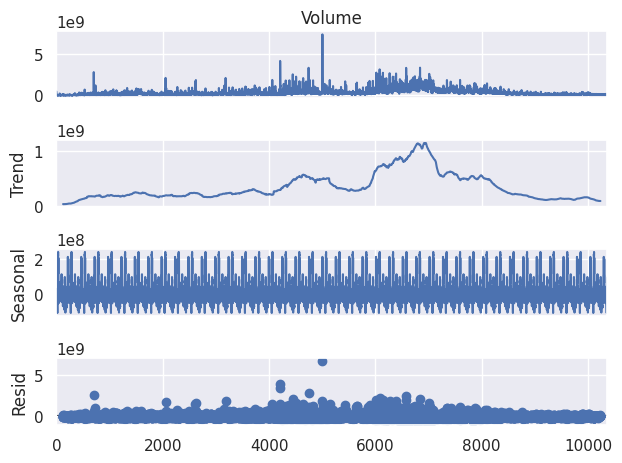

In [ ]:
# decomposition method to check Seasonality trend , cycling,stationary or non stationary data
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
decompose = seasonal_decompose(df_date['Volume'], period=252)
decompose.plot()
plt.show()

In [ ]:
df_date['Date'] = pd.to_datetime(df_date['Date'])

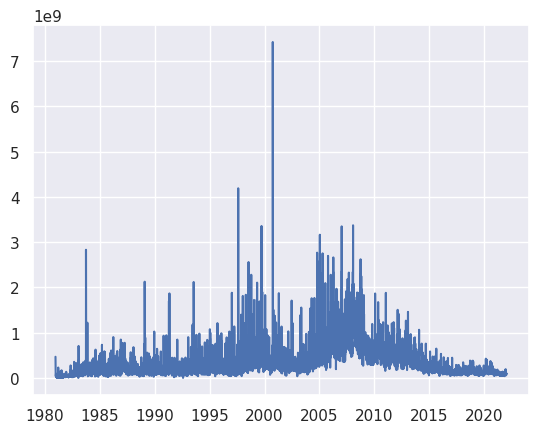

In [ ]:
plt.plot(df_date['Date'], df_date['Volume'])
plt.show()

In [ ]:
df_date['Volume'].describe()

,Volume
count,1.036000e+04
mean,3.332944e+08
std,3.397429e+08
min,0.000000e+00
25%,1.259076e+08
50%,2.217230e+08
75%,4.147584e+08
max,7.421641e+09


In [ ]:
df_final = pd.read_csv('/content/AAPL.csv', parse_dates= True, index_col=0)

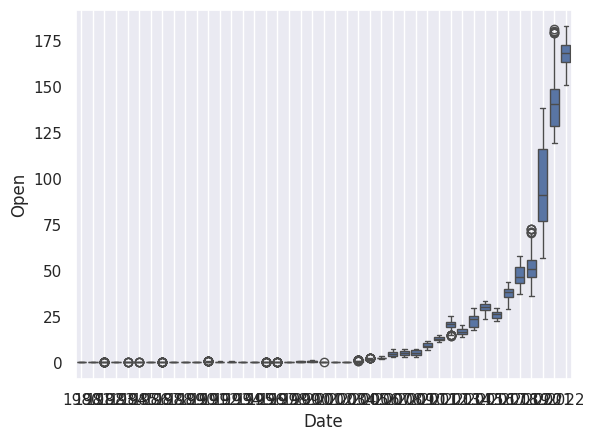

In [ ]:
# Checking Outlier
sns.boxplot(x = df_final.index.year, y = df_final['Open'])
plt.grid()

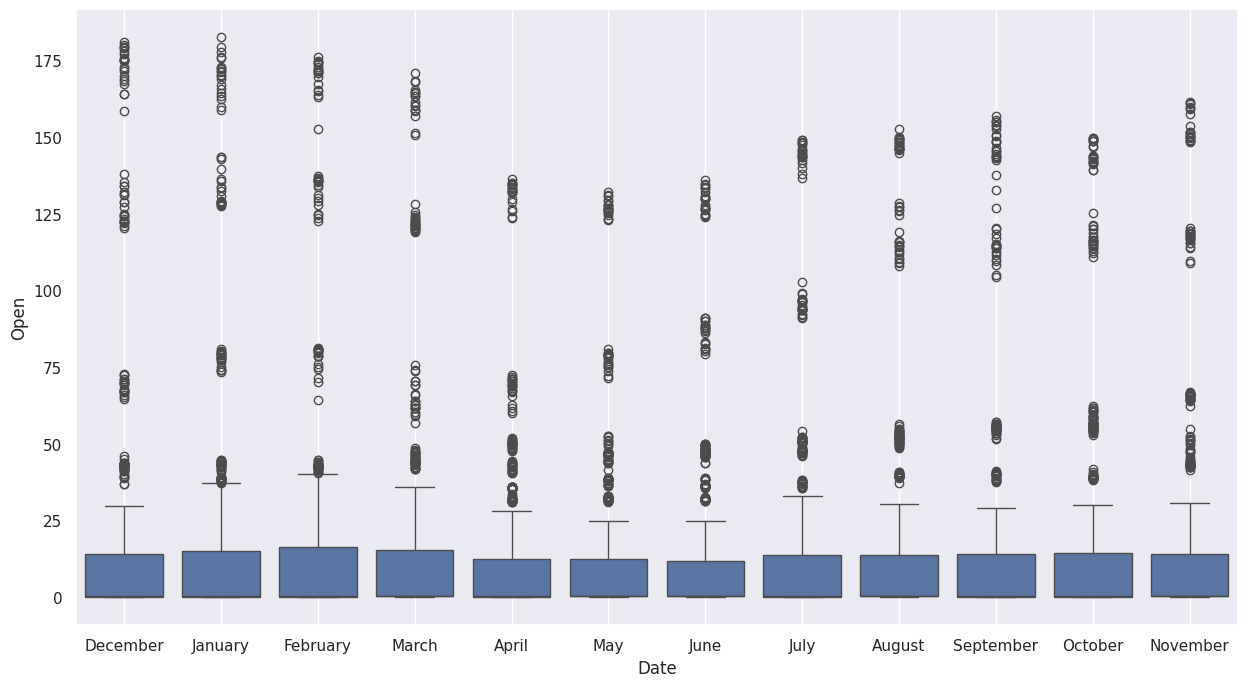

In [ ]:
# Plotting a sns BoxPLot for entire month
from pylab import rcParams
rcParams['figure.figsize'] = 15, 8
sns.boxplot(x = df_final.index.month_name(), y = df_final['Open'])
plt.grid()

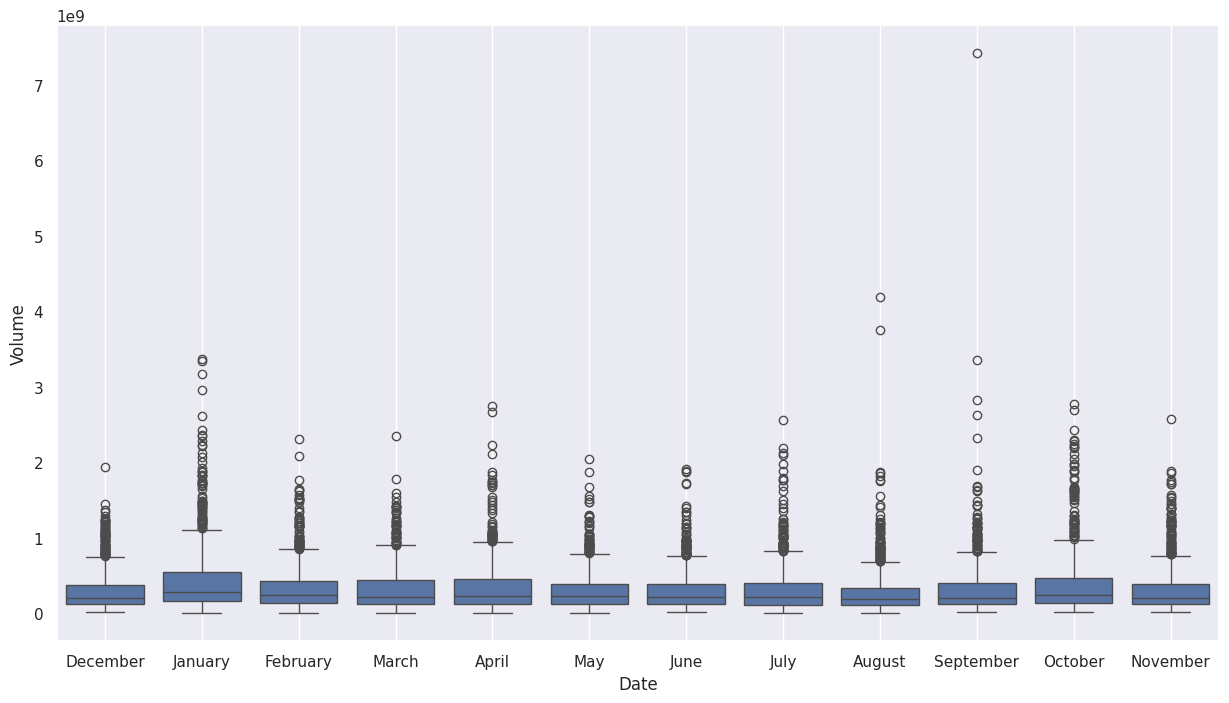

In [ ]:
# boxplot for Volume data
sns.boxplot(x = df_final.index.month_name(), y = df_final['Volume'])
plt.grid()

In [ ]:
# Here it will create a 2 cols and in that cols it will store MONTH & YEAR
df_final['Month'] = df_final.index.month
df_final['Year'] = df_final.index.year
df_final

,Open,High,Low,Close,Adj Close,Volume,Month,Year
Date,,,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100323,469033600,12,1980
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095089,175884800,12,1980
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.088110,105728000,12,1980
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090291,86441600,12,1980
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092908,73449600,12,1980
...,...,...,...,...,...,...,...,...
2022-03-18,160.509995,164.479996,159.759995,163.979996,163.979996,123351200,3,2022
2022-03-21,163.509995,166.350006,163.009995,165.380005,165.380005,95811400,3,2022
2022-03-22,165.509995,169.419998,164.910004,168.820007,168.820007,81532000,3,2022


In [ ]:
df['Time_Stamp'] = pd.to_datetime(df_date['Time_Stamp'])
df_final_model = df.set_index('Time_Stamp')
df_final_model

,Date,Open,High,Low,Close,Adj Close,Volume
Time_Stamp,,,,,,,
1980-12-12,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100323,469033600
1980-12-15,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095089,175884800
1980-12-16,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.088110,105728000
1980-12-17,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090291,86441600
1980-12-18,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092908,73449600
...,...,...,...,...,...,...,...
NaT,2022-03-18,160.509995,164.479996,159.759995,163.979996,163.979996,123351200
NaT,2022-03-21,163.509995,166.350006,163.009995,165.380005,165.380005,95811400
NaT,2022-03-22,165.509995,169.419998,164.910004,168.820007,168.820007,81532000


In [ ]:
df_final_model.index.isnull().sum()

np.int64(49)

In [ ]:
df_final_model['Date'] = pd.to_datetime(df_final_model['Date'])
df_final_model.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10409 entries, 1980-12-12 to NaT
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       10409 non-null  datetime64[ns]
 1   Open       10409 non-null  float64       
 2   High       10409 non-null  float64       
 3   Low        10409 non-null  float64       
 4   Close      10409 non-null  float64       
 5   Adj Close  10409 non-null  float64       
 6   Volume     10409 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 650.6 KB


In [ ]:
df_final_model.head()

,Date,Open,High,Low,Close,Adj Close,Volume
Time_Stamp,,,,,,,
1980-12-12,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100323,469033600
1980-12-15,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095089,175884800
1980-12-16,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.088110,105728000
1980-12-17,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090291,86441600
1980-12-18,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092908,73449600


In [ ]:
df_final_model.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
Time_Stamp,,,,,,,
NaT,2022-03-18,160.509995,164.479996,159.759995,163.979996,163.979996,123351200
NaT,2022-03-21,163.509995,166.350006,163.009995,165.380005,165.380005,95811400
NaT,2022-03-22,165.509995,169.419998,164.910004,168.820007,168.820007,81532000
NaT,2022-03-23,167.990005,172.639999,167.649994,170.210007,170.210007,98062700
NaT,2022-03-24,171.059998,174.139999,170.210007,174.070007,174.070007,90018700


In [ ]:
# show only rows where the timestamp data is missing
df_final_model[df_final_model.index.isnull()]

,Date,Open,High,Low,Close,Adj Close,Volume
Time_Stamp,,,,,,,
NaT,2022-01-13,175.779999,176.619995,171.789993,172.190002,171.970901,84505800
NaT,2022-01-14,171.339996,173.779999,171.089996,173.070007,172.849792,80440800
NaT,2022-01-18,171.509995,172.539993,169.410004,169.800003,169.583939,90956700
NaT,2022-01-19,170.000000,171.080002,165.940002,166.229996,166.018478,94815000
NaT,2022-01-20,166.979996,169.679993,164.179993,164.509995,164.300659,91420500
NaT,2022-01-21,164.419998,166.330002,162.300003,162.410004,162.203354,122848900
NaT,2022-01-24,160.020004,162.300003,154.699997,161.619995,161.414337,162294600
NaT,2022-01-25,158.979996,162.759995,157.020004,159.779999,159.576691,115798400
NaT,2022-01-26,163.500000,164.389999,157.820007,159.690002,159.486801,108275300


In [ ]:
# filling missing values in Time_Stamp from Date column
df_final_model.index = pd.to_datetime(df_final_model['Date'])
df_final_model.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,,
2022-03-18,2022-03-18,160.509995,164.479996,159.759995,163.979996,163.979996,123351200
2022-03-21,2022-03-21,163.509995,166.350006,163.009995,165.380005,165.380005,95811400
2022-03-22,2022-03-22,165.509995,169.419998,164.910004,168.820007,168.820007,81532000
2022-03-23,2022-03-23,167.990005,172.639999,167.649994,170.210007,170.210007,98062700
2022-03-24,2022-03-24,171.059998,174.139999,170.210007,174.070007,174.070007,90018700


In [ ]:
# reanaming for index
df_final_model.index.name ='Time_Stamp'

In [ ]:
len(df_final_model)

10409

In [ ]:
df_final_model.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
Time_Stamp,,,,,,,
2022-03-18,2022-03-18,160.509995,164.479996,159.759995,163.979996,163.979996,123351200
2022-03-21,2022-03-21,163.509995,166.350006,163.009995,165.380005,165.380005,95811400
2022-03-22,2022-03-22,165.509995,169.419998,164.910004,168.820007,168.820007,81532000
2022-03-23,2022-03-23,167.990005,172.639999,167.649994,170.210007,170.210007,98062700
2022-03-24,2022-03-24,171.059998,174.139999,170.210007,174.070007,174.070007,90018700


In [ ]:
# Spliting the dataset for Train and Test (very important)
train = df_final_model.iloc[:7286]
test = df_final_model.iloc[7286:]

In [ ]:
train.shape

(7286, 7)

In [ ]:
test.shape

(3123, 7)

In [ ]:
train_final = train[['Volume']]
test_final = test[['Volume']]

In [ ]:
train_final.head()


,Volume
Time_Stamp,
1980-12-12,469033600
1980-12-15,175884800
1980-12-16,105728000
1980-12-17,86441600
1980-12-18,73449600


In [ ]:
train_final.tail()

,Volume
Time_Stamp,
2009-10-21,1193726800
2009-10-22,791392000
2009-10-23,420786800
2009-10-26,484338400
2009-10-27,756551600


Automation Method-Facebook Prophet Model

In [ ]:
! pip install prophet

In [ ]:
import prophet
from prophet import Prophet

In [ ]:
dir(prophet)

['Path',
 'Prophet',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'about',
 'diagnostics',
 'f',
 'forecaster',
 'here',
 'make_holidays',
 'models',
 'plot']

In [ ]:
# Creating a model
model = Prophet

In [ ]:
# copying the data to another tabel
df_final_model1 = df_final_model[['Date','Volume']]
df_final_model1

,Date,Volume
Time_Stamp,,
1980-12-12,1980-12-12,469033600
1980-12-15,1980-12-15,175884800
1980-12-16,1980-12-16,105728000
1980-12-17,1980-12-17,86441600
1980-12-18,1980-12-18,73449600
...,...,...
2022-03-18,2022-03-18,123351200
2022-03-21,2022-03-21,95811400
2022-03-22,2022-03-22,81532000


In [ ]:
model = Prophet()
df_prophet = df_final_model1.rename(columns={'Date': 'ds', 'Volume': 'y'})
model.fit(df_prophet)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
model.component_modes

{'additive': ['yearly',
  'weekly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [ ]:
df_prophet

,ds,y
Time_Stamp,,
1980-12-12,1980-12-12,469033600
1980-12-15,1980-12-15,175884800
1980-12-16,1980-12-16,105728000
1980-12-17,1980-12-17,86441600
1980-12-18,1980-12-18,73449600
...,...,...
2022-03-18,2022-03-18,123351200
2022-03-21,2022-03-21,95811400
2022-03-22,2022-03-22,81532000


In [ ]:
# creatine future dataframe
future_dates = model.make_future_dataframe(periods=100)
future_dates.tail()

,ds
10504,2022-06-28
10505,2022-06-29
10506,2022-06-30
10507,2022-07-01
10508,2022-07-02


In [ ]:
# predicting future
pred = model.predict(future_dates)
pred

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1980-12-12,8.428383e+07,-3.320929e+08,2.842765e+08,8.428383e+07,8.428383e+07,-1.053299e+08,-1.053299e+08,-1.053299e+08,-8.600620e+07,-8.600620e+07,-8.600620e+07,-1.932374e+07,-1.932374e+07,-1.932374e+07,0.0,0.0,0.0,-2.104610e+07
1,1980-12-15,8.475918e+07,-3.452178e+08,2.604430e+08,8.475918e+07,8.475918e+07,-1.368407e+08,-1.368407e+08,-1.368407e+08,-9.928620e+07,-9.928620e+07,-9.928620e+07,-3.755447e+07,-3.755447e+07,-3.755447e+07,0.0,0.0,0.0,-5.208149e+07
2,1980-12-16,8.491763e+07,-3.477402e+08,2.621353e+08,8.491763e+07,8.491763e+07,-1.156959e+08,-1.156959e+08,-1.156959e+08,-7.251821e+07,-7.251821e+07,-7.251821e+07,-4.317766e+07,-4.317766e+07,-4.317766e+07,0.0,0.0,0.0,-3.077824e+07
3,1980-12-17,8.507608e+07,-3.287393e+08,2.855756e+08,8.507608e+07,8.507608e+07,-1.085566e+08,-1.085566e+08,-1.085566e+08,-6.027377e+07,-6.027377e+07,-6.027377e+07,-4.828281e+07,-4.828281e+07,-4.828281e+07,0.0,0.0,0.0,-2.348050e+07
4,1980-12-18,8.523453e+07,-3.367438e+08,2.585276e+08,8.523453e+07,8.523453e+07,-1.188712e+08,-1.188712e+08,-1.188712e+08,-6.616964e+07,-6.616964e+07,-6.616964e+07,-5.270156e+07,-5.270156e+07,-5.270156e+07,0.0,0.0,0.0,-3.363667e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10504,2022-06-28,1.233340e+08,-3.168118e+08,2.988929e+08,1.233340e+08,1.233340e+08,-1.311218e+08,-1.311218e+08,-1.311218e+08,-7.251821e+07,-7.251821e+07,-7.251821e+07,-5.860357e+07,-5.860357e+07,-5.860357e+07,0.0,0.0,0.0,-7.787732e+06
10505,2022-06-29,1.232633e+08,-2.723046e+08,3.173018e+08,1.232633e+08,1.232633e+08,-1.178434e+08,-1.178434e+08,-1.178434e+08,-6.027377e+07,-6.027377e+07,-6.027377e+07,-5.756966e+07,-5.756966e+07,-5.756966e+07,0.0,0.0,0.0,5.419910e+06
10506,2022-06-30,1.231926e+08,-2.798371e+08,3.167385e+08,1.231926e+08,1.231926e+08,-1.221099e+08,-1.221099e+08,-1.221099e+08,-6.616964e+07,-6.616964e+07,-6.616964e+07,-5.594026e+07,-5.594026e+07,-5.594026e+07,0.0,0.0,0.0,1.082740e+06
10507,2022-07-01,1.231219e+08,-3.021449e+08,2.764085e+08,1.231219e+08,1.231219e+08,-1.397517e+08,-1.397517e+08,-1.397517e+08,-8.600620e+07,-8.600620e+07,-8.600620e+07,-5.374550e+07,-5.374550e+07,-5.374550e+07,0.0,0.0,0.0,-1.662976e+07


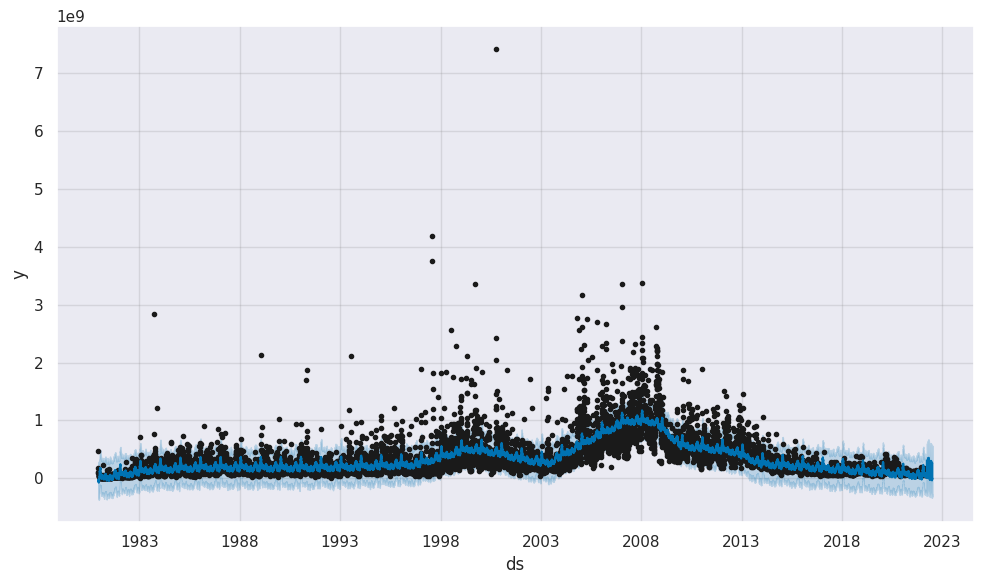

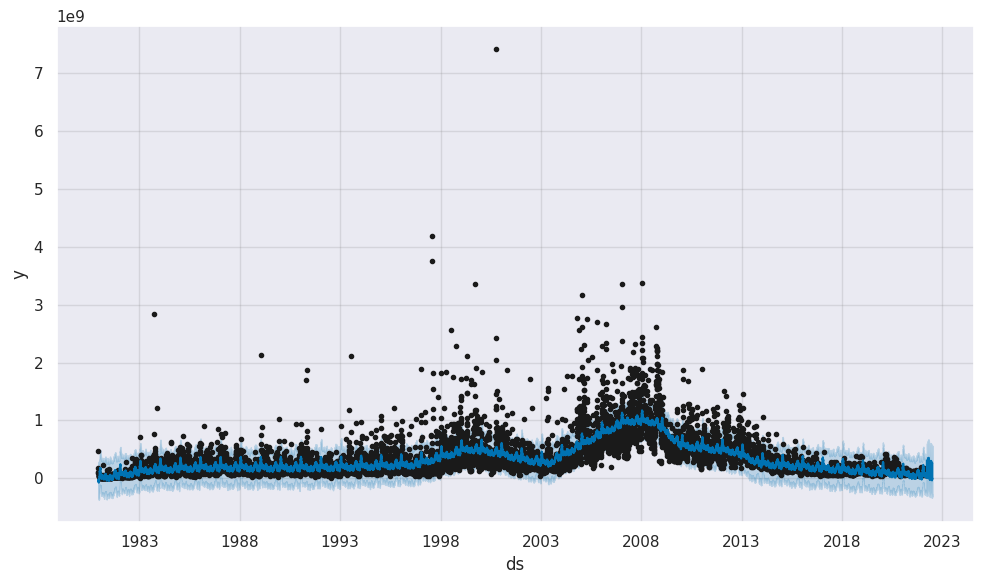

In [ ]:
# plotting the future data
model.plot(pred)

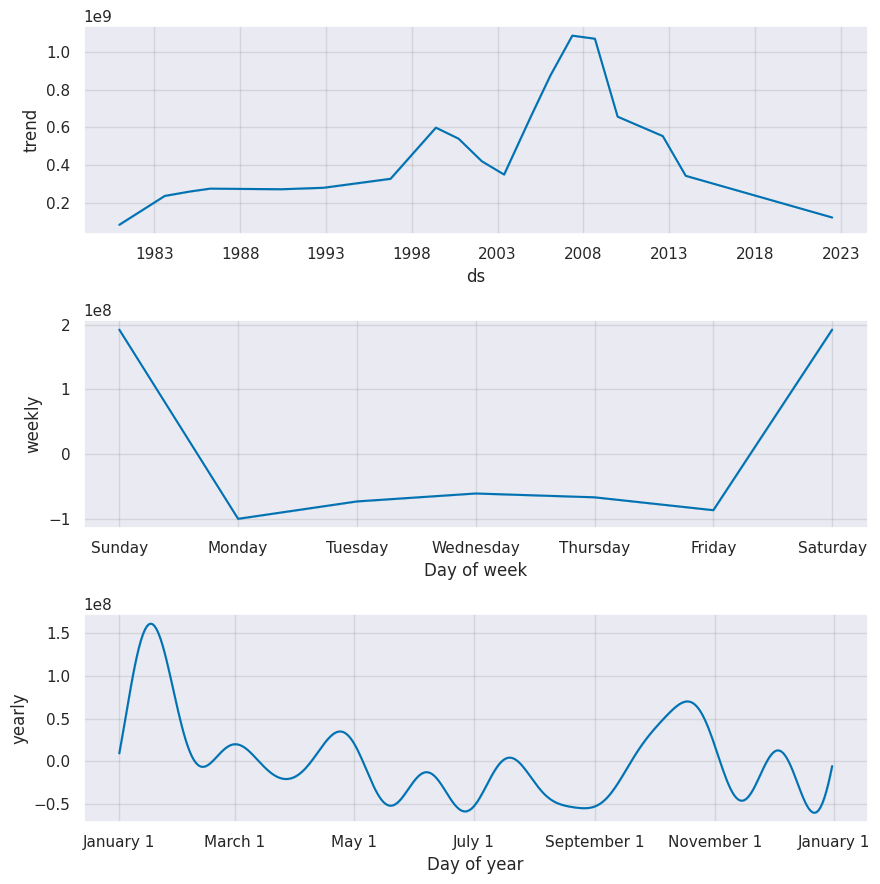

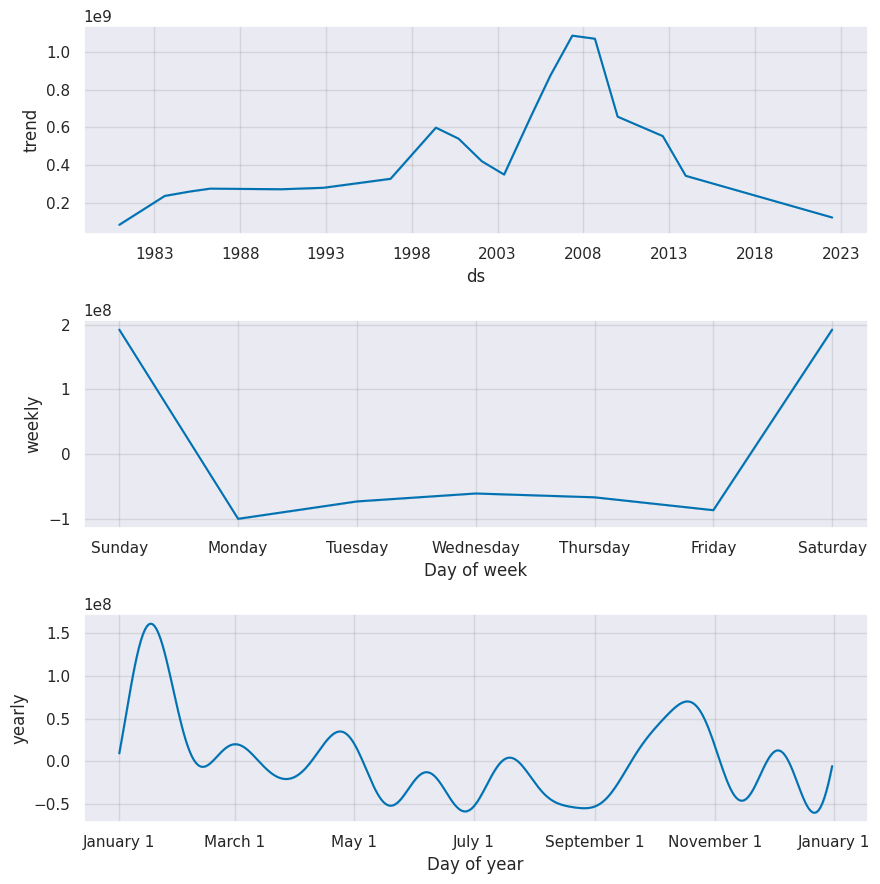

In [ ]:
model.plot_components(pred)